In [20]:
import pandas as pd
import yfinance as yf

# 17 Indian stocks (NSE)
ticks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "SBIN.NS",
    "LT.NS",
    "BHARTIARTL.NS",
    "ITC.NS",
    "HINDUNILVR.NS",
    "KOTAKBANK.NS",
    "AXISBANK.NS",
    "MARUTI.NS",
    "ASIANPAINT.NS",    # replaced TATAMOTORS.NS
    "SUNPHARMA.NS",
    "WIPRO.NS",
    "ADANIENT.NS"
]

def get_historical_Data(tickers):
    """Returns dataframe with adjusted historical closing prices"""

    # Download all stocks together (faster and fewer errors)
    stock_data = yf.download(
        tickers,
        start="2020-10-27",
        end="2021-10-27",
        auto_adjust=True,
        group_by='ticker',
        progress=False
    )

    data = pd.DataFrame()

    for stock in tickers:
        try:
            data[stock] = stock_data[stock]["Close"]
        except Exception:
            print(f"Could not download {stock}")

    return data


# Get data
d = get_historical_Data(ticks)

# Shape of dataframe
print("Shape:", d.shape)

# Show latest rows
print(d.tail())

Shape: (248, 17)
            RELIANCE.NS       TCS.NS      INFY.NS  HDFCBANK.NS  ICICIBANK.NS  \
Date                                                                           
2021-10-20  1228.714478  3201.062744  1603.766602   796.145813    723.489136   
2021-10-21  1193.268921  3133.340332  1560.432495   797.311218    732.849731   
2021-10-22  1195.498657  3103.492188  1530.312134   799.427734    736.535767   
2021-10-25  1183.850342  3098.259277  1519.411865   788.131287    816.465454   
2021-10-26  1210.809814  3089.078613  1529.421265   786.109924    804.534180   

               SBIN.NS        LT.NS  BHARTIARTL.NS      ITC.NS  HINDUNILVR.NS  \
Date                                                                            
2021-10-20  457.282166  1717.088745     692.410583  199.460266    2295.872559   
2021-10-21  460.072113  1716.185913     680.291260  197.923462    2265.398682   
2021-10-22  460.072113  1703.355469     678.776428  191.371841    2273.133057   
2021-10-25  463.3

In [21]:
corr_matrix = d.corr()
corr_matrix

,RELIANCE.NS,TCS.NS,INFY.NS,HDFCBANK.NS,ICICIBANK.NS,SBIN.NS,LT.NS,BHARTIARTL.NS,ITC.NS,HINDUNILVR.NS,KOTAKBANK.NS,AXISBANK.NS,MARUTI.NS,ASIANPAINT.NS,SUNPHARMA.NS,WIPRO.NS,ADANIENT.NS
RELIANCE.NS,1.000000,0.763048,0.754013,0.715566,0.721831,0.705718,0.738801,0.788118,0.743493,0.688602,0.443658,0.672427,0.070546,0.723961,0.750658,0.778868,0.633539
TCS.NS,0.763048,1.000000,0.919127,0.732791,0.848542,0.790615,0.885237,0.896518,0.795168,0.907380,0.230803,0.805485,-0.026115,0.873665,0.889359,0.907349,0.772089
INFY.NS,0.754013,0.919127,1.000000,0.687541,0.903765,0.868752,0.904336,0.790757,0.754720,0.834803,0.109537,0.825986,-0.068245,0.905886,0.935571,0.959739,0.872071
HDFCBANK.NS,0.715566,0.732791,0.687541,1.000000,0.835630,0.809995,0.869081,0.778322,0.833397,0.535703,0.565527,0.883679,0.163265,0.579764,0.716106,0.672522,0.571764
ICICIBANK.NS,0.721831,0.848542,0.903765,0.835630,1.000000,0.961958,0.966203,0.807046,0.814546,0.693992,0.250901,0.956290,-0.082410,0.810311,0.933788,0.917368,0.862607
SBIN.NS,0.705718,0.790615,0.868752,0.809995,0.961958,1.000000,0.940164,0.705532,0.801303,0.623564,0.185875,0.952994,-0.082481,0.780742,0.886197,0.878082,0.905007
LT.NS,0.738801,0.885237,0.904336,0.869081,0.966203,0.940164,1.000000,0.849280,0.881799,0.720782,0.339215,0.943154,0.040568,0.816656,0.911851,0.891492,0.805916
BHARTIARTL.NS,0.788118,0.896518,0.790757,0.778322,0.807046,0.705532,0.849280,1.000000,0.844097,0.771191,0.492090,0.754237,0.078182,0.727846,0.836144,0.813745,0.584295
ITC.NS,0.743493,0.795168,0.754720,0.833397,0.814546,0.801303,0.881799,0.844097,1.000000,0.686364,0.569512,0.805866,0.169604,0.711398,0.800547,0.746380,0.640758
HINDUNILVR.NS,0.688602,0.907380,0.834803,0.535703,0.693992,0.623564,0.720782,0.771191,0.686364,1.000000,0.181054,0.626132,-0.057373,0.893495,0.806923,0.825562,0.706658


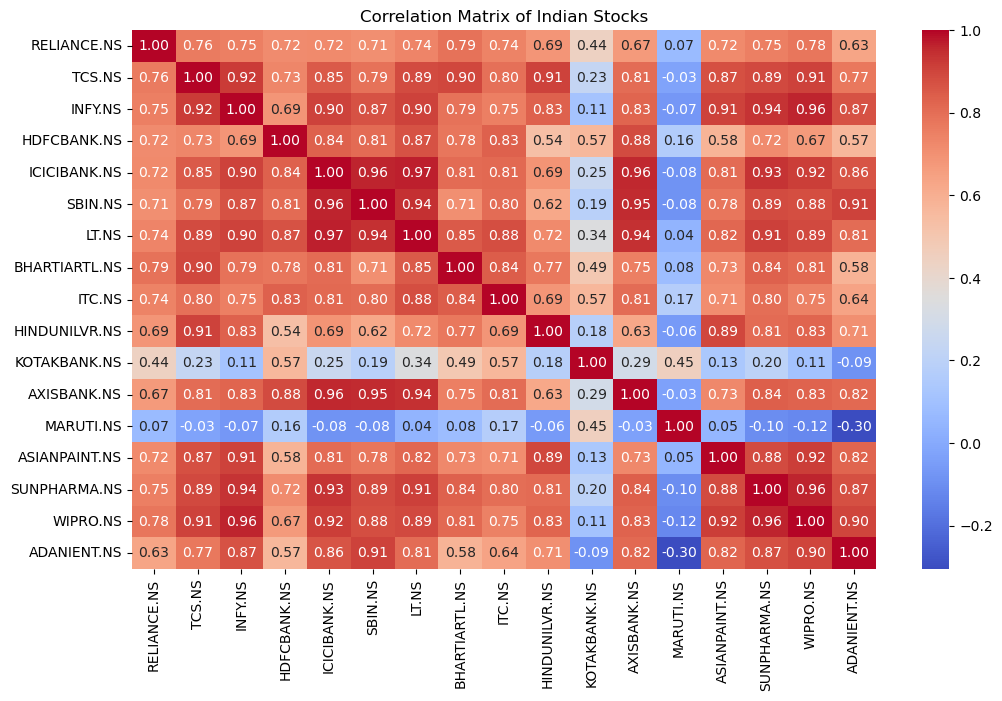

In [22]:
import seaborn as sn
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

figure(figsize=(12,7), dpi=100)

sn.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Indian Stocks")
plt.show()

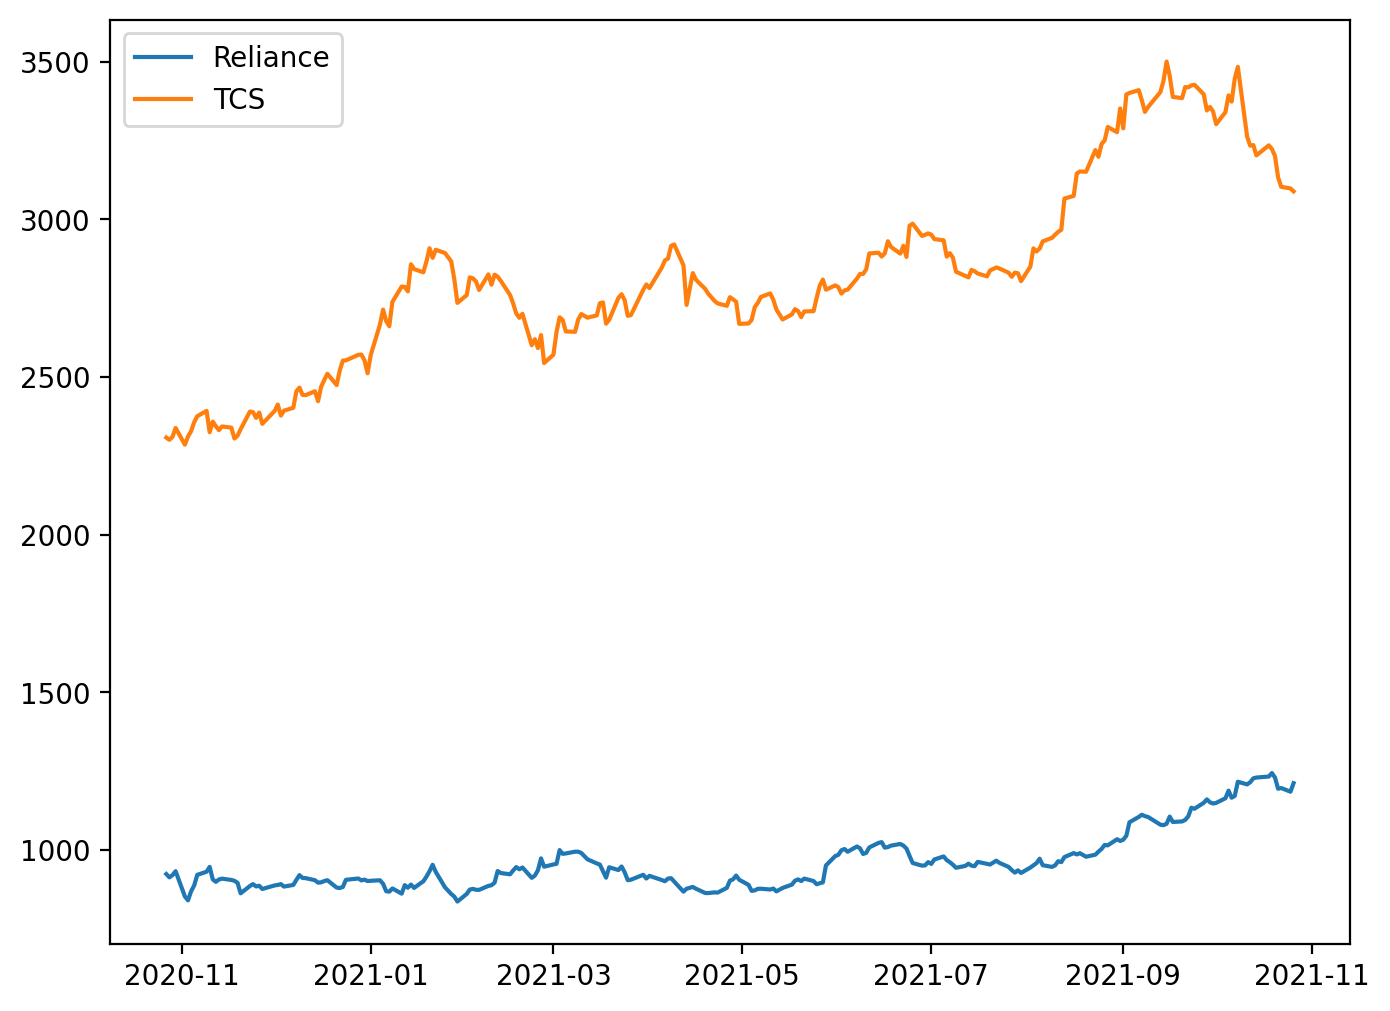

In [23]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=200)

RELIANCE = d['RELIANCE.NS']
TCS = d['TCS.NS']

# Check out the relationship between the stocks
plt.plot(RELIANCE, label="Reliance")
plt.plot(TCS, label="TCS")

plt.legend()
plt.show()

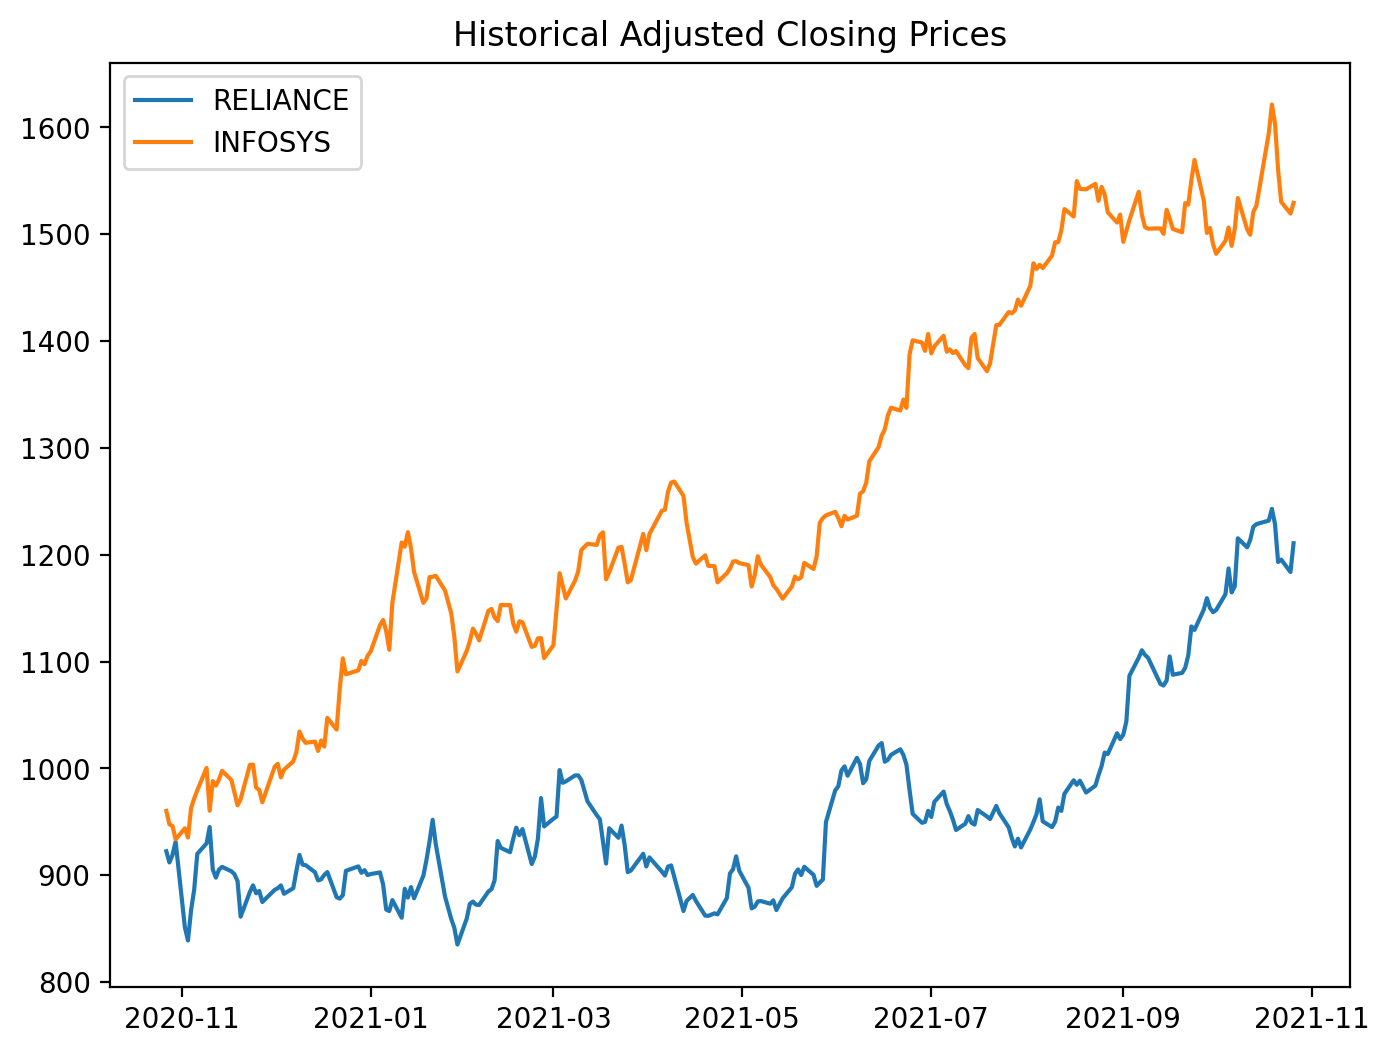

In [24]:
figure(figsize=(8, 6), dpi=200)

RELIANCE = d['RELIANCE.NS']
INFY = d['INFY.NS']

plt.plot(RELIANCE, label="RELIANCE")
plt.plot(INFY, label="INFOSYS")

plt.title('Historical Adjusted Closing Prices')
plt.legend()

plt.show()

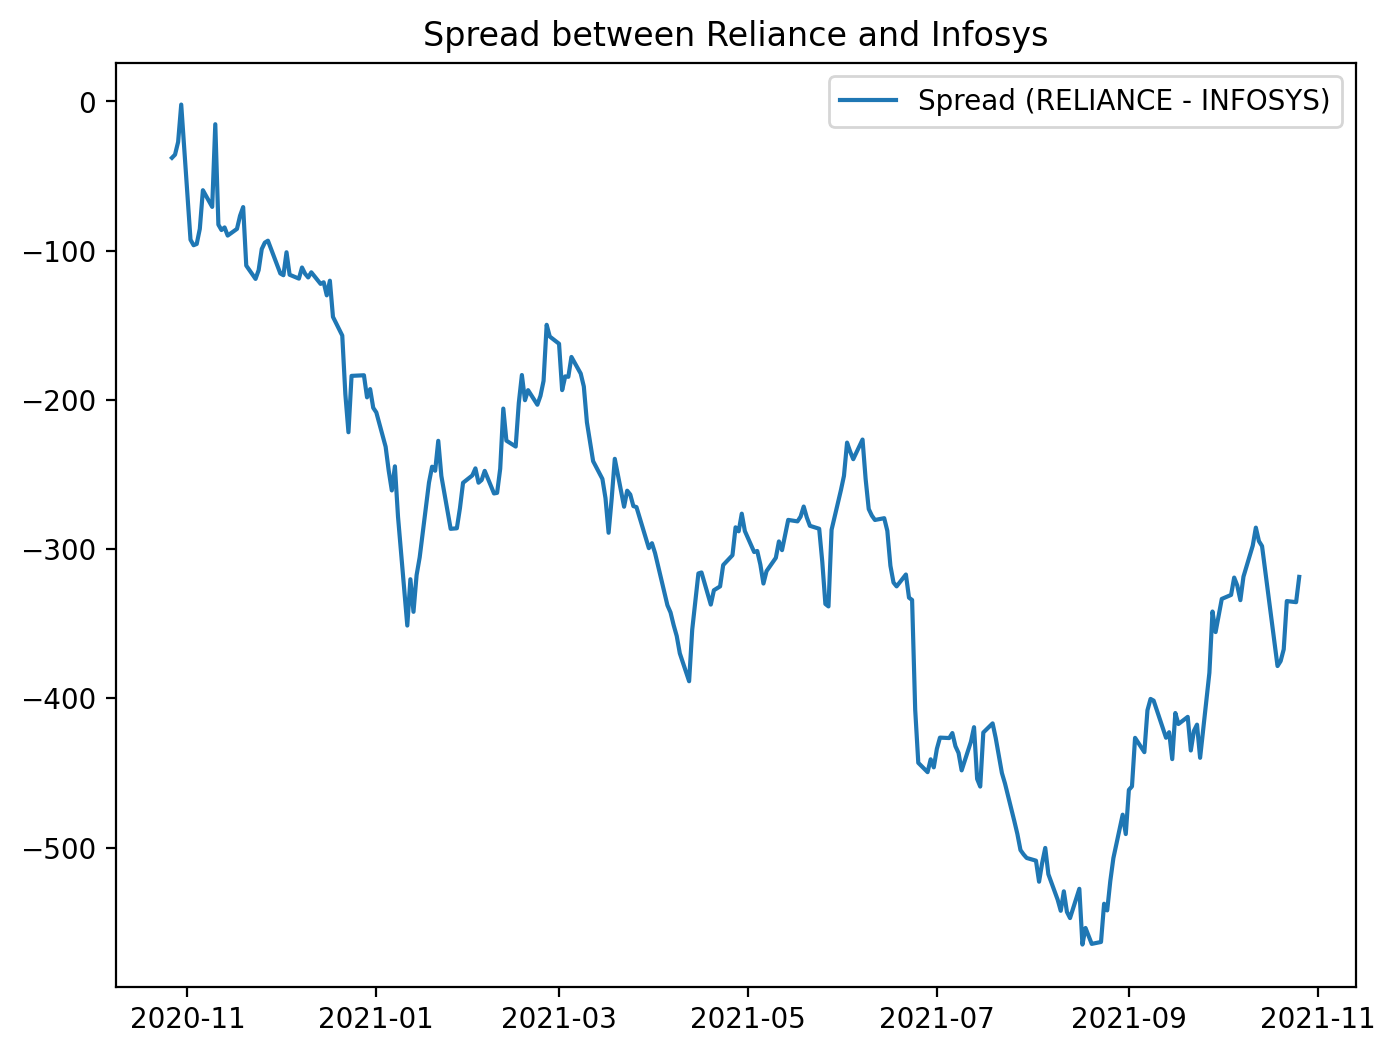

In [25]:
figure(figsize=(8, 6), dpi=200)

plt.plot(RELIANCE - INFY, label='Spread (RELIANCE - INFOSYS)')

plt.legend()
plt.title("Spread between Reliance and Infosys")

plt.show()

In [26]:
import statsmodels.tsa.stattools as ts

result = ts.coint(RELIANCE, INFY)

print(result)

(np.float64(-1.621626904817668), np.float64(0.7116756751791115), array([-3.94132922, -3.36097908, -3.06166543]))


In [27]:
cointegration_t_statistic = result[0]
p_val = result[1]
critical_values_test_statistic_at_1_5_10 = result[2]

print('We want P value < 0.05 (meaning cointegration may exist)')
print('P value for Reliance and Infosys cointegration test:', p_val)

We want P value < 0.05 (meaning cointegration may exist)
P value for Reliance and Infosys cointegration test: 0.7116756751791115


In [28]:
from statsmodels.tsa.stattools import adfuller

# Compute ADF test for Reliance and Infosys
# We want stationary data (P-value < 0.05)

# ADF for Reliance
RELIANCE_ADF = adfuller(RELIANCE)
print('P value for Reliance ADF Test:', RELIANCE_ADF[1])

# ADF for Infosys
INFY_ADF = adfuller(INFY)
print('P value for Infosys ADF Test:', INFY_ADF[1])

# ADF for Spread
Spread_ADF = adfuller(RELIANCE - INFY)
print('P value for Spread ADF Test:', Spread_ADF[1])

# ADF for Ratio
Ratio_ADF = adfuller(RELIANCE / INFY)
print('P value for Ratio ADF Test:', Ratio_ADF[1])

# Interpretation:
# P-value < 0.05 → stationary
# P-value > 0.05 → non-stationary

P value for Reliance ADF Test: 0.9318545539553929
P value for Infosys ADF Test: 0.77526562221603
P value for Spread ADF Test: 0.24922404768122086
P value for Ratio ADF Test: 0.1085363989087888


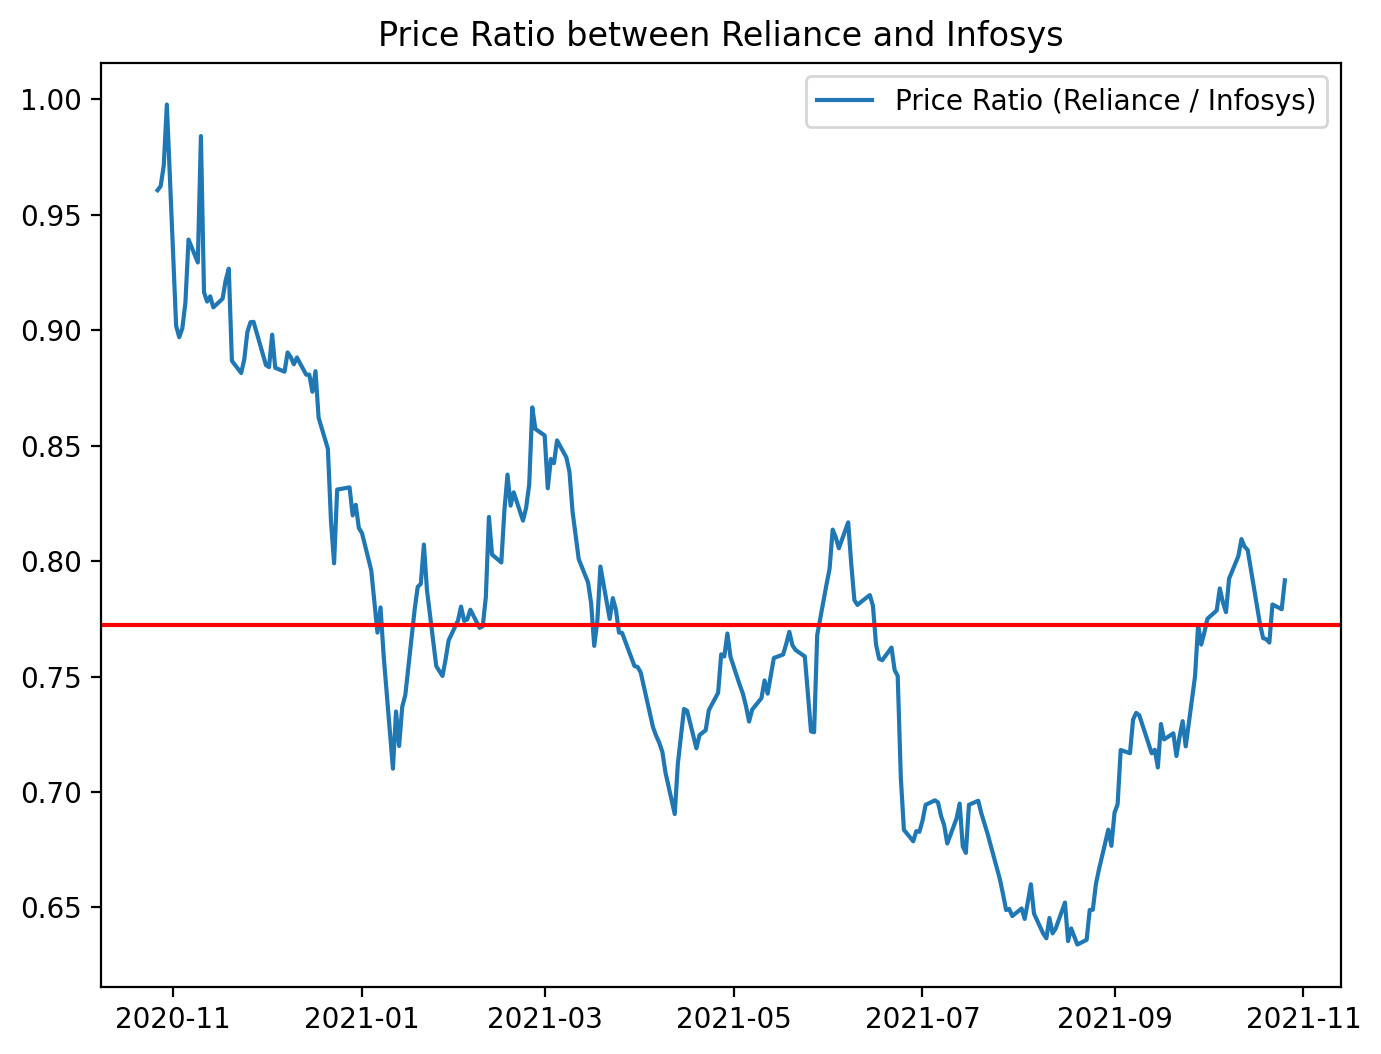

In [29]:
# Take a look at the price ratio between the two time series

figure(figsize=(8, 6), dpi=200)

ratio = RELIANCE / INFY

plt.plot(ratio, label='Price Ratio (Reliance / Infosys)')
plt.axhline(ratio.mean(), color='red')

plt.legend()
plt.title("Price Ratio between Reliance and Infosys")

plt.show()

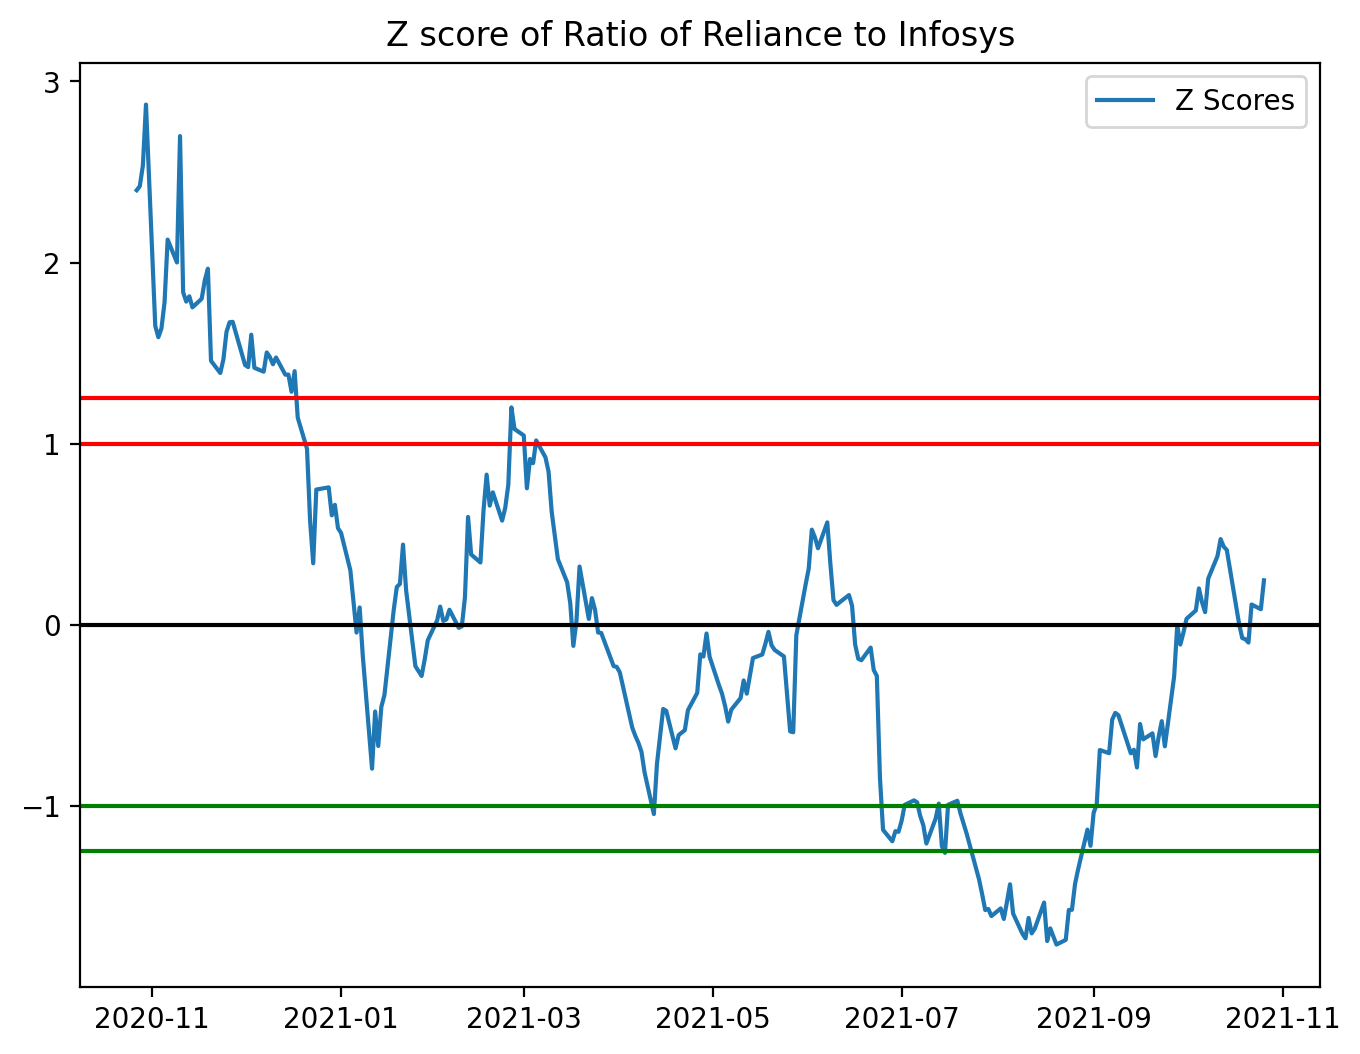

In [30]:
# NOTE: We will use the Price Ratio approach and standardize it

figure(figsize=(8, 6), dpi=200)

# Calculate Z-scores
df_zscore = (ratio - ratio.mean()) / ratio.std()

plt.plot(df_zscore, label="Z Scores")

plt.axhline(df_zscore.mean(), color='black')
plt.axhline(1.0, color='red')
plt.axhline(1.25, color='red')

plt.axhline(-1.0, color='green')
plt.axhline(-1.25, color='green')

plt.legend(loc='best')
plt.title('Z score of Ratio of Reliance to Infosys')

plt.show()

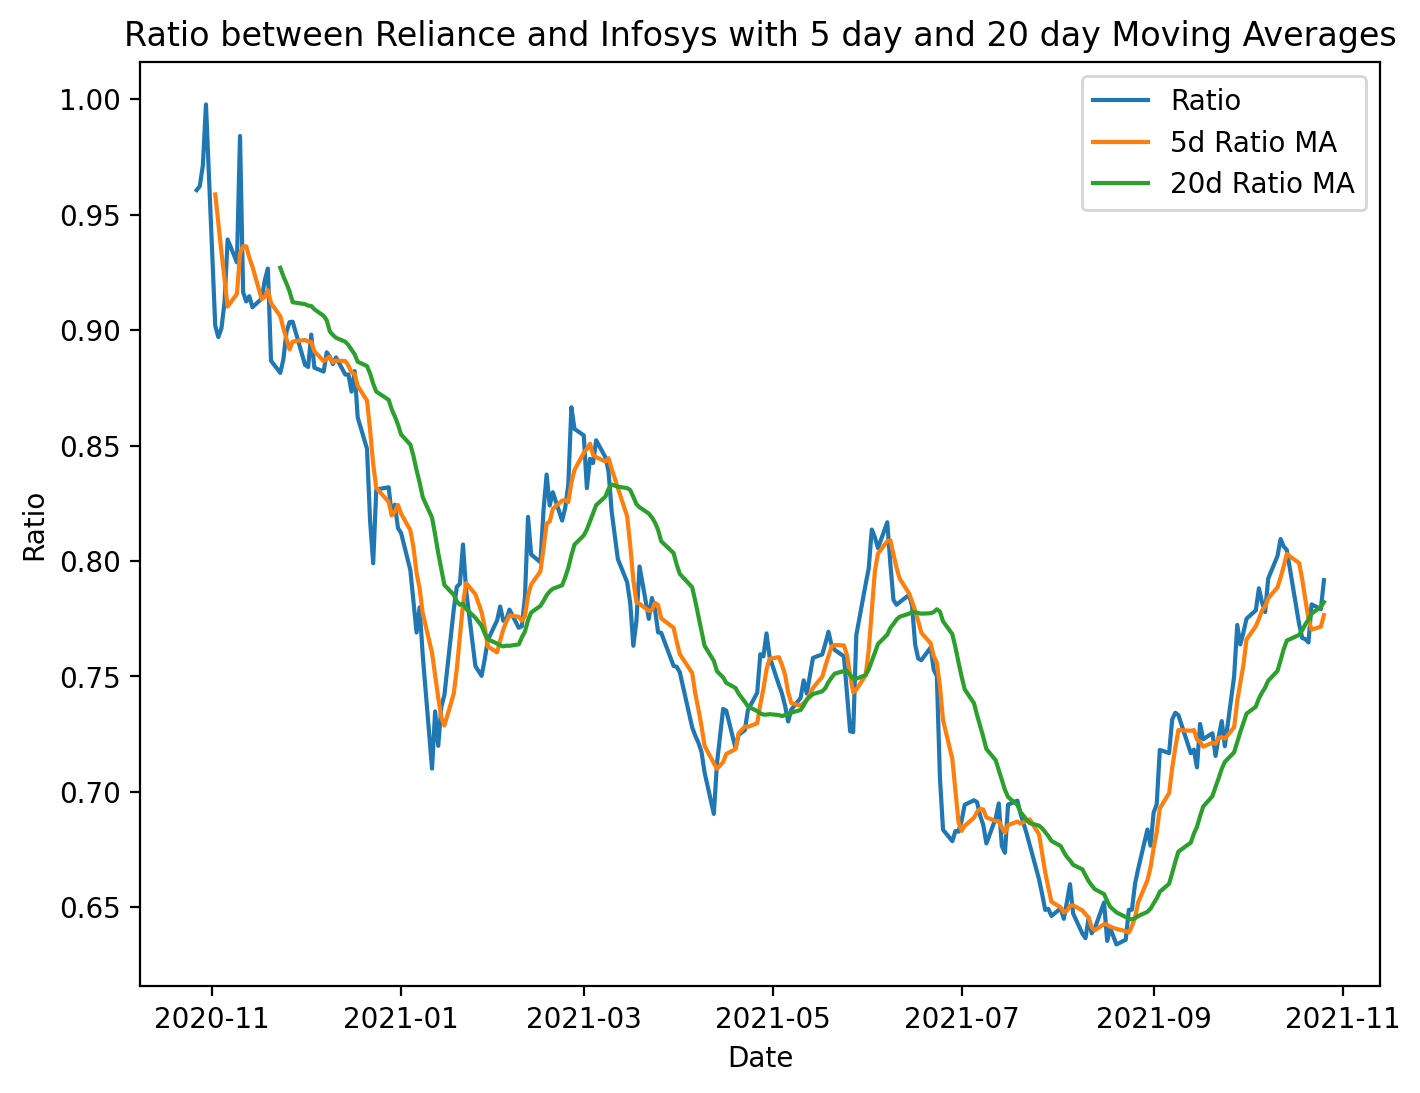

In [31]:
figure(figsize=(8, 6), dpi=200)

ratios_mavg5 = ratio.rolling(window=5, center=False).mean()
ratios_mavg20 = ratio.rolling(window=20, center=False).mean()

std_20 = ratio.rolling(window=20, center=False).std()

zscore_20_5 = (ratios_mavg5 - ratios_mavg20) / std_20

plt.plot(ratio.index, ratio.values)
plt.plot(ratios_mavg5.index, ratios_mavg5.values)
plt.plot(ratios_mavg20.index, ratios_mavg20.values)

plt.legend(['Ratio', '5d Ratio MA', '20d Ratio MA'])

plt.xlabel('Date')
plt.ylabel('Ratio')
plt.title('Ratio between Reliance and Infosys with 5 day and 20 day Moving Averages')

plt.show()

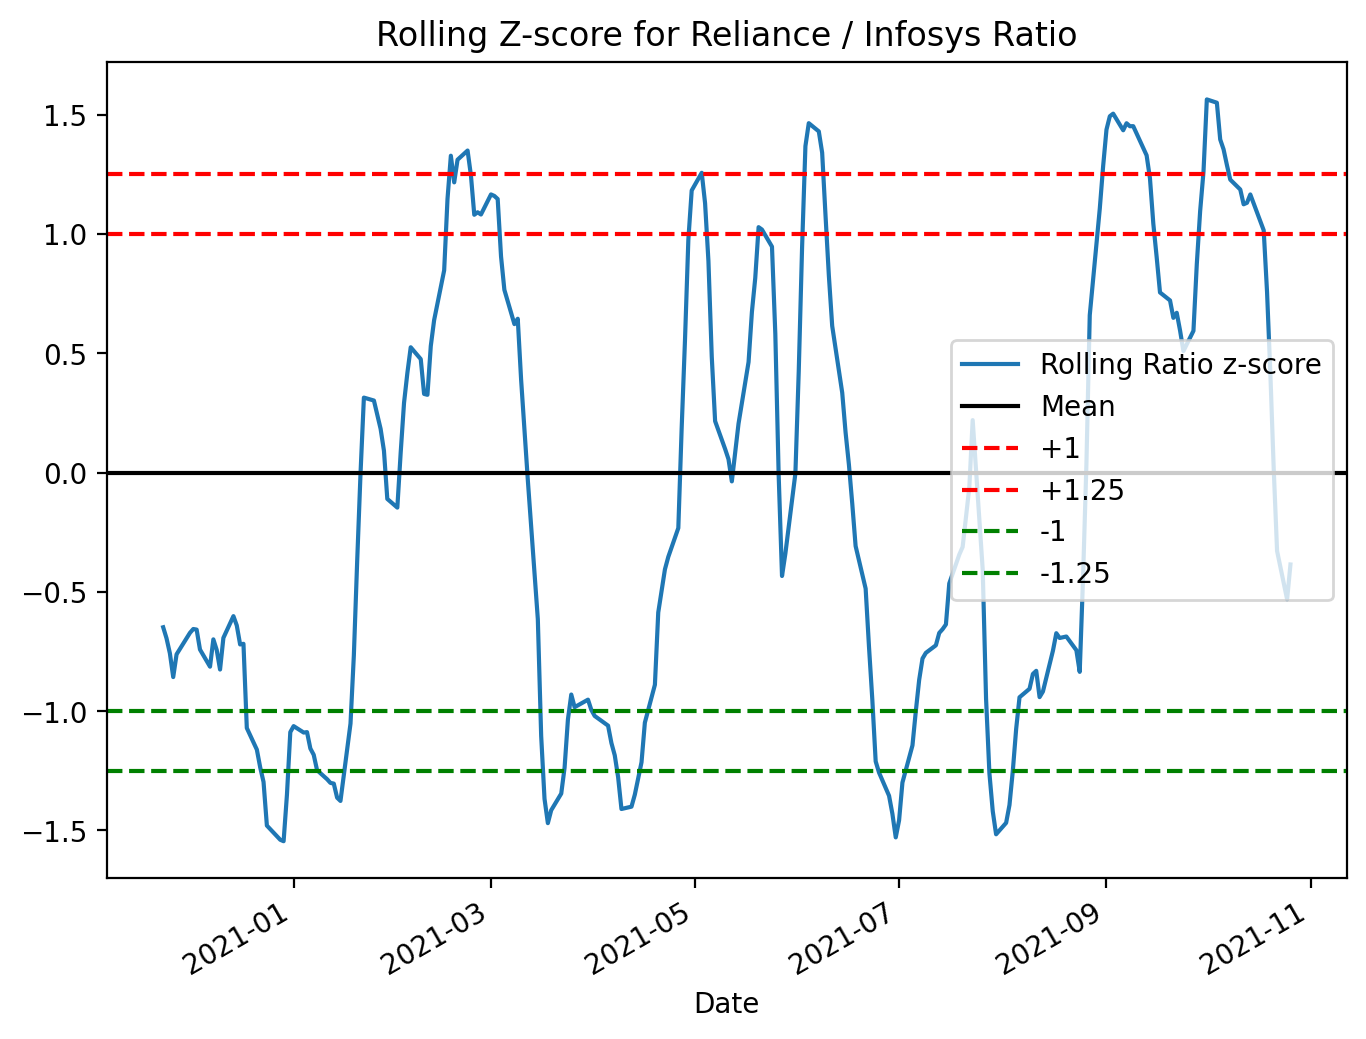

In [32]:
figure(figsize=(8, 6), dpi=200)

zscore_20_5.plot()

plt.axhline(0, color='black')
plt.axhline(1, color='red', linestyle='--')
plt.axhline(1.25, color='red', linestyle='--')
plt.axhline(-1, color='green', linestyle='--')
plt.axhline(-1.25, color='green', linestyle='--')

plt.legend([
    'Rolling Ratio z-score',
    'Mean',
    '+1',
    '+1.25',
    '-1',
    '-1.25'
])

plt.title('Rolling Z-score for Reliance / Infosys Ratio')

plt.show()

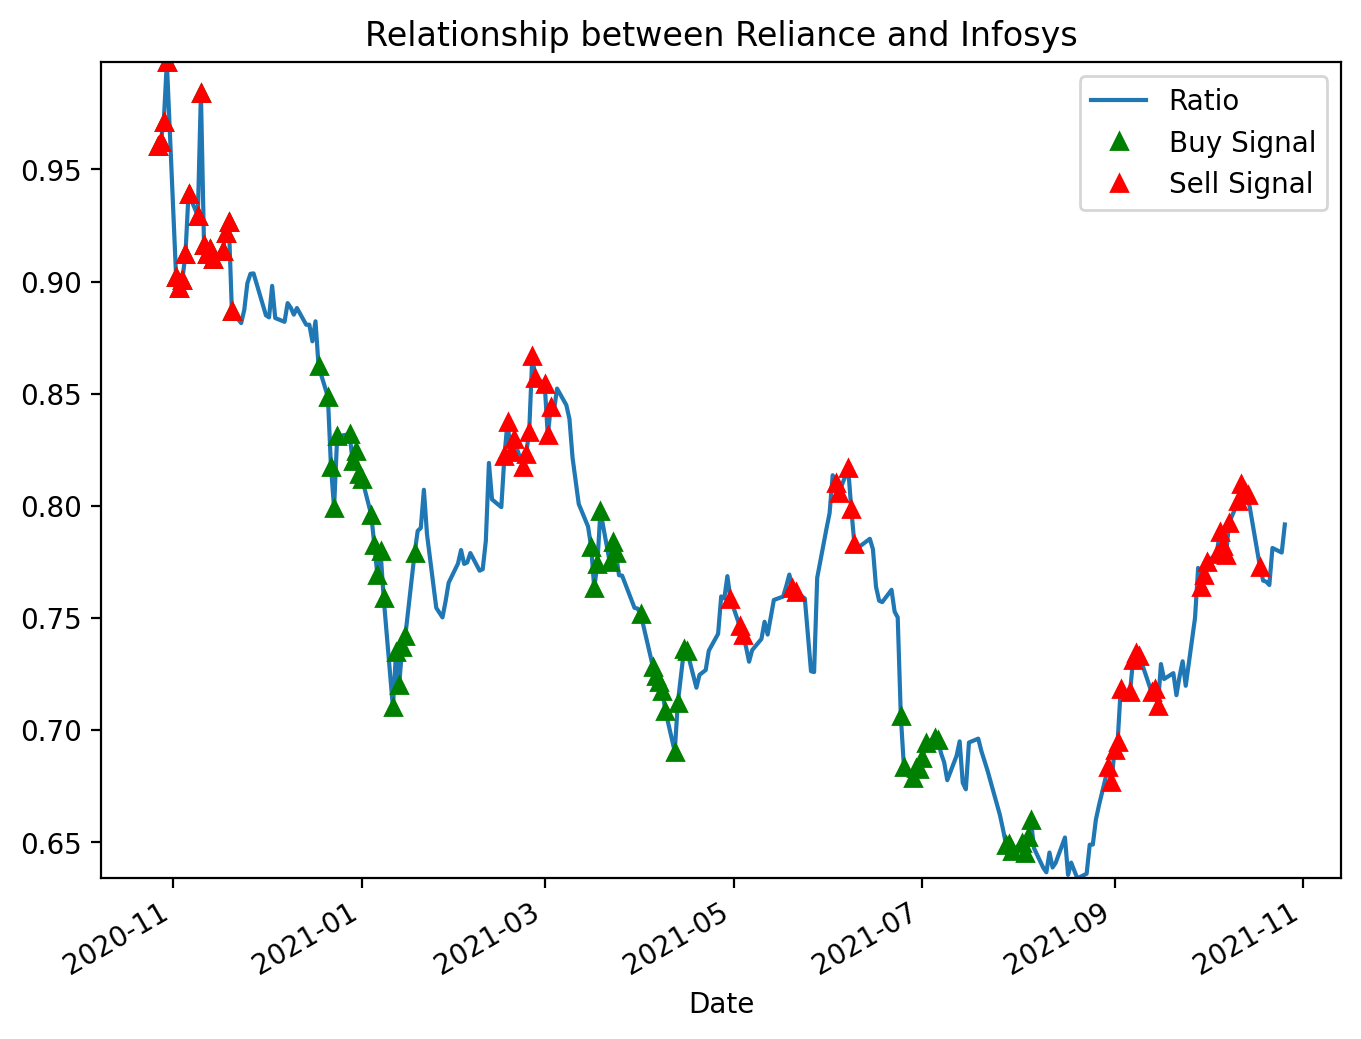

In [33]:
figure(figsize=(8, 6), dpi=200)

ratio.plot()

buy = ratio.copy()
sell = ratio.copy()

buy[zscore_20_5 > -1] = 0
sell[zscore_20_5 < 1] = 0

buy.plot(color='g', linestyle='None', marker='^')
sell.plot(color='r', linestyle='None', marker='^')

x1, x2, y1, y2 = plt.axis()
plt.axis((x1, x2, ratio.min(), ratio.max()))

plt.legend(['Ratio', 'Buy Signal', 'Sell Signal'])

plt.title('Relationship between Reliance and Infosys')

plt.show()